# **TFM – Desarrollo de un sistema de recomendación de intervenciones de mantenimiento preventivo para máquinas industriales**

**Máster:** Big Data y Ciencia de Datos  
**Universidad:** Universidad Internacional de Valencia - VIU  
**Autor:** Wilder Fernando Aguilar Quispe
**Tutor:** Pedro Álvarez Torres
**Fecha:** Mayo 2026

## **DESCRIPCIÓN**
Este notebook implementa el pipeline experimental utilizado en el TFM:
"Desarrollo de un sistema de recomendación de intervenciones de mantenimiento preventivo para máquinas industriales".

Incluye:
- Preprocesamiento de datos
- Análisis exploratorio
- Entrenamiento de modelos
- Evaluación
- Interpretación de resultados

## **IMPORTACIÓN DE LIBRERIAS**

In [ ]:
# ==================================================
# LIBRERÍAS
# ==================================================
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import os

from google.colab import files
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

## **CARGA DE DATOS**

In [ ]:
# ==================================================
# CARGA DE DATOS
# ==================================================

# 1. Botón interactivo para subir el archivo
print("Por favor, selecciona el archivo del dataset AI4I 2020:")
uploaded = files.upload()

# 2. Capturamos el nombre exacto del archivo
nombre_archivo = list(uploaded.keys())[0]

# 3. Lectura del archivo y lo convertimos en un DataFrame
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

# 4. Confirmación
print(f"\nEl archivo '{nombre_archivo}' se ha cargado correctamente.")
print(f"La tabla tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

Por favor, selecciona el archivo del dataset AI4I 2020:


Saving ai4i2020.csv to ai4i2020.csv

El archivo 'ai4i2020.csv' se ha cargado correctamente.
La tabla tiene 10000 filas y 14 columnas.


## **INSPECCIÓN INICIAL DEL DATASET**

En esta sección se analiza la estructura general del conjunto de datos.

In [ ]:
# =========================================================
# INSPECCIÓN INICIAL DEL DATASET
# =========================================================

print("Dimensión del dataset (filas, columnas):")
print(df.shape)

print("\n--- PRIMERAS FILAS DEL DATASET ---")
display(df.head())

print("\n--- INFORMACIÓN GENERAL DEL DATASET ---")
df.info()

Dimensión del dataset (filas, columnas):
(10000, 14)

--- PRIMERAS FILAS DEL DATASET ---


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



--- INFORMACIÓN GENERAL DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-n

#### Observaciones iniciales

En la inspección preliminar del dataset se pueden identificar lo siguiente:

- Contiene 10.000 registros y 14 variables.
- No contiene valores nulos.
- Existen variables numéricas relacionadas con sensores de la máquina (temperatura, velocidad, torque y desgaste).
- También se incluyen variables categóricas como el tipo de producto.

## **ESTADÍSTICA DESCRIPTIVA**

In [ ]:
# =========================================================
# ESTADÍSTICA DESCRIPTIVA DE VARIABLES NUMÉRICAS
# =========================================================

# Eliminamos UDI ya que no aporta información analítica
df_numeric = df.drop(columns=["UDI"])

print("--- ESTADÍSTICA DESCRIPTIVA (sin identificador) ---")
display(df_numeric.describe())

--- ESTADÍSTICA DESCRIPTIVA (sin identificador) ---


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Observaciones descriptivas del dataset
*   Las variables de temperatura presentan una variabilidad baja. Los valores de la media y desviación estandar de la temperatura del aire y la temperatura del proceso indican condiciones operativas estables.
*   La velocidad de rotación presenta una media de 1539 rpm con una desviación estándar de 179 rpm, lo que refleja una variabilidad moderada en la operación de las máquinas.
*   El torque muestra una media de 40 Nm y un rango que oscila entre 3.8 Nm y 76.6 Nm, sugiriendo diferentes niveles de carga durante el funcionamiento del equipo.
*   La variable de desgaste de herramienta presenta una media de 108 minutos, con valor máximo que alcanza los 253 minutos, indicando que se incluyen máquinas con distintos niveles de desgaste acumulado.
*   En cuanto a la variable "fallo de máquina" ("Machine failure"), se tiene una media de 0.0339, lo que sugiere un dataset desbalanceado. En ese sentido se realizara un análisis de distribución de fallos.

## **DISTRIBUCIÓN DE FALLOS**
Analizaremos la frecuencia de los eventos de fallo registrados, para comprender la proporción entre condiciones normales de operación y
eventos de fallo de la máquina.

In [ ]:
# =========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# =========================================================

print("--- DISTRIBUCIÓN DE FALLOS DE MÁQUINA ---")

failure_counts = df["Machine failure"].value_counts()

display(failure_counts)

--- DISTRIBUCIÓN DE FALLOS DE MÁQUINA ---


,count
Machine failure,
0,9661
1,339


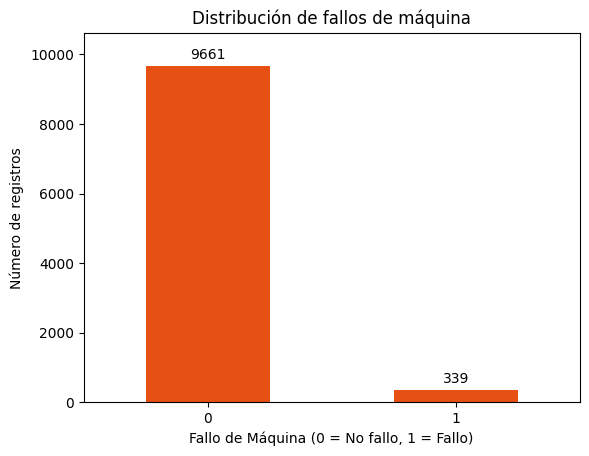

In [ ]:
ax = failure_counts.plot(kind="bar", color="#E65113")

ax.bar_label(ax.containers[0], padding=3)
plt.ylim(0, failure_counts.max() * 1.1)

plt.title("Distribución de fallos de máquina")
plt.xlabel("Fallo de Máquina (0 = No fallo, 1 = Fallo)")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)
plt.show()

### Observaciones

El análisis de la variable "Machine failure" muestra que los eventos de fallo representan una proporción reducida del conjunto de datos.

Aproximadamente el 3.39% de los registros corresponden a fallos de máquina, mientras que la gran mayoría de observaciones representan condiciones normales de operación. Este comportamiento refleja una característica típica de los sistemas industriales, donde los eventos de fallo son relativamente poco frecuentes.

Esta distribución sugiere la presencia de un dataset desbalanceado, lo cual debe tenerse en cuenta en las etapas posteriores de modelado y evaluación de los algoritmos de Machine Learning.

### **Distribución de tipos de fallo**

El dataset incluye variables que identifican distintos tipos de fallo que permiten caracterizar las posibles causas de las interrupciones en el funcionamiento de la máquina, tales como desgaste de herramienta (TWF), problemas de disipación térmica (HDF), fallos de potencia (PWF), sobreesfuerzo mecánico (OSF) o fallos aleatorios (RNF).

El análisis de su distribución permite identificar cuáles son los eventos de fallo más frecuentes dentro del sistema.

In [ ]:
# =========================================================
# DISTRIBUCIÓN DE TIPOS DE FALLO
# =========================================================

failure_types = df[["TWF","HDF","PWF","OSF","RNF"]].sum()

failure_summary = failure_types.to_frame(name="Número de eventos")
failure_summary.loc["TOTAL"] = failure_summary["Número de eventos"].sum()

display(failure_summary)

,Número de eventos
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19
TOTAL,373


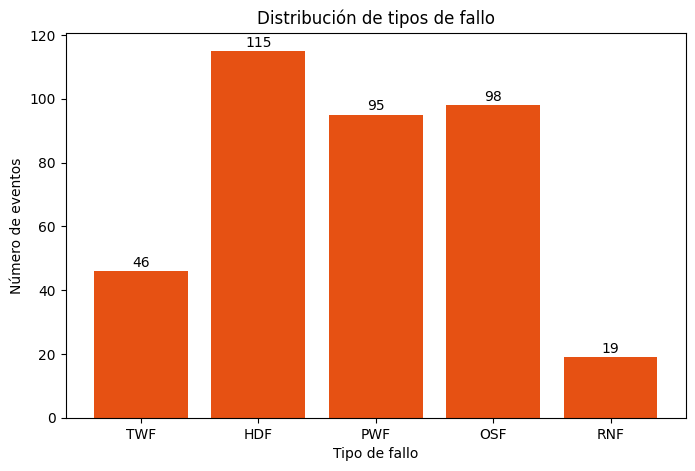

In [ ]:
# Gráfico de barras
plt.figure(figsize=(8,5))
bars = plt.bar(failure_types.index, failure_types.values, color="#E65113")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)), ha='center', va='bottom')

plt.title("Distribución de tipos de fallo")
plt.xlabel("Tipo de fallo")
plt.ylabel("Número de eventos")
plt.xticks(rotation=0)
plt.show()


### Observaciones

El análisis muestra que los eventos no se distribuyen de manera uniforme entre los tipos de fallo. El más frecuente corresponde a los problemas de HDF con 115 eventos registrados. Le siguen los fallos por OSF con 98 casos y los fallos relacionados con PWF con 95 eventos. Los fallos asociados a TWF presentan una menor frecuencia, con 46 registros; mientras que los RNF constituyen la categoría menos frecuente con 19 casos.

Estos resultados sugieren que los problemas térmicos y las condiciones de carga mecánica podrían desempeñar un papel relevante en la ocurrencia de fallos en el sistema analizado.

El número total de eventos asociados a los tipos de fallo es 373 y recordemos que el número total de fallos de máquina registrados en "Machine failure" es 339, lo que indica que algunos registros pueden estar asociados a más de un tipo de fallo simultáneamente.

## **Análisis exploratorio de variables operativas**

El objetivo de este análisis es comprender la distribución de las principales variables que describen el estado de operación del sistema, así como identificar posibles valores atípicos o patrones que puedan estar asociados con la aparición de fallos.

Las variables analizadas incluyen las temperaturas del sistema, la velocidad de rotación, el torque aplicado y el desgaste acumulado de la herramienta. Estas variables representan condiciones físicas relevantes en el funcionamiento de la máquina y pueden proporcionar información valiosa para anticipar eventos de fallo.

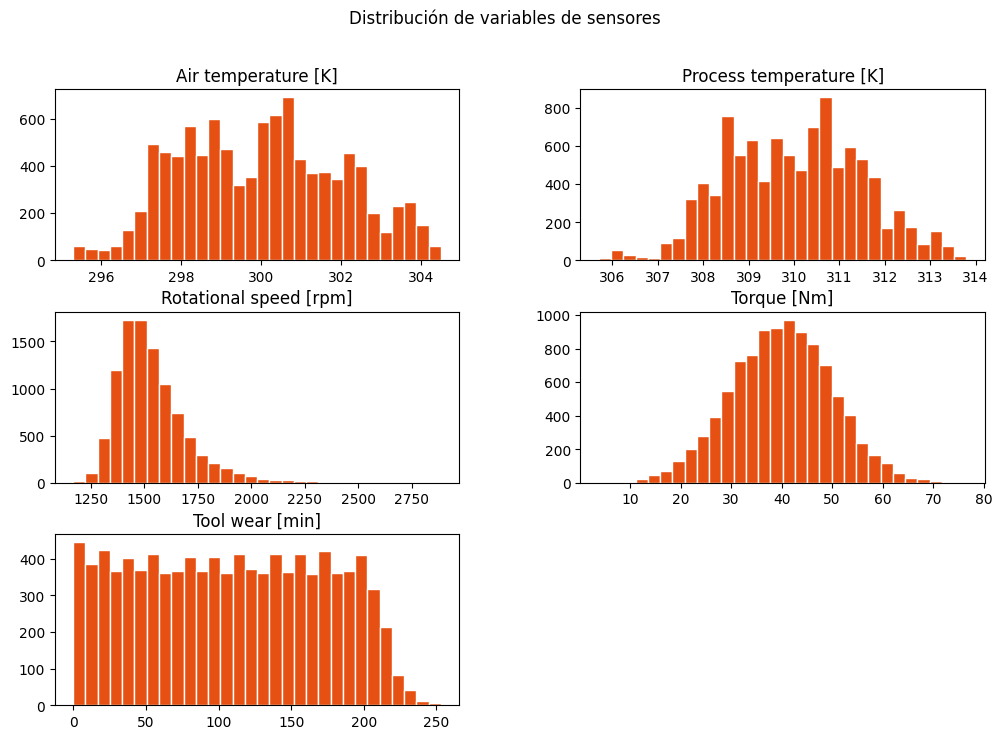

In [ ]:
# =========================================================
# DISTRIBUCIÓN DE VARIABLES DE SENSORES
# =========================================================
sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[sensor_columns].hist(
    figsize=(12,8),
    bins=30,
    color="#E65113",
    edgecolor="white",
    grid=False
)

plt.suptitle("Distribución de variables de sensores")
plt.show()

### Observaciones

**Air temperature [K] (Temperatura del aire):**  
Presenta una distribución multimodal, concentrándose principalmente entre los 297 K y 303 K. La presencia de varios picos sugiere que la máquina opera bajo distintos estados térmicos del entorno. Estas variaciones podrían estar asociadas a diferentes condiciones operativas del sistema o cambios en el entorno de operación.

**Process temperature [K] (Temperatura del proceso):**  
La distribución es similar a la temperatura del aire, con valores que oscilan aproximadamente entre 307 K y 312 K y con múltiples picos. Este comportamiento sugiere una posible relación entre ambas temperaturas, lo que indicaría que las condiciones térmicas del entorno pueden influir en la temperatura del proceso durante la operación de la máquina.

**Rotational speed [rpm] (Velocidad de rotación):**  
La distribución presenta una ligera asimetría positiva. La mayor parte de las observaciones se concentra en torno a valores cercanos a 1400–1500 rpm, lo que sugiere que la máquina opera mayormente en un rango de velocidad moderado. Sin embargo, la presencia de una cola hacia valores más altos indica que, en ciertos casos, el sistema puede operar a velocidades considerablemente superiores.

**Torque [Nm] (Fuerza de torsión):**  
Esta variable muestra una distribución normal, centrada en torno a los 40 Nm. Este comportamiento indica que el esfuerzo de torsión aplicado durante la operación de la máquina se mantiene dentro de un rango relativamente estable, con variaciones simétricas alrededor del valor medio.

**Tool wear [min] (Desgaste de la herramienta):**  
Presenta principalmente una distribución uniforme, lo que indica que el dataset incluye observaciones de herramientas con diferentes niveles de uso acumulado. Asimismo, se observa una disminución en la frecuencia de registros para niveles muy elevados de desgaste, lo que sugiere la existencia de límites operativos o políticas de reemplazo antes de alcanzar niveles extremos de deterioro.

### **Detección de valores atípicos**

En mantenimiento predictivo, la detección de valores atípicos resulta  relevante, ya que estos pueden reflejar estados de operación inusuales o situaciones cercanas a fallos en los equipos industriales. Para este análisis se emplean diagramas de caja (*boxplots*).

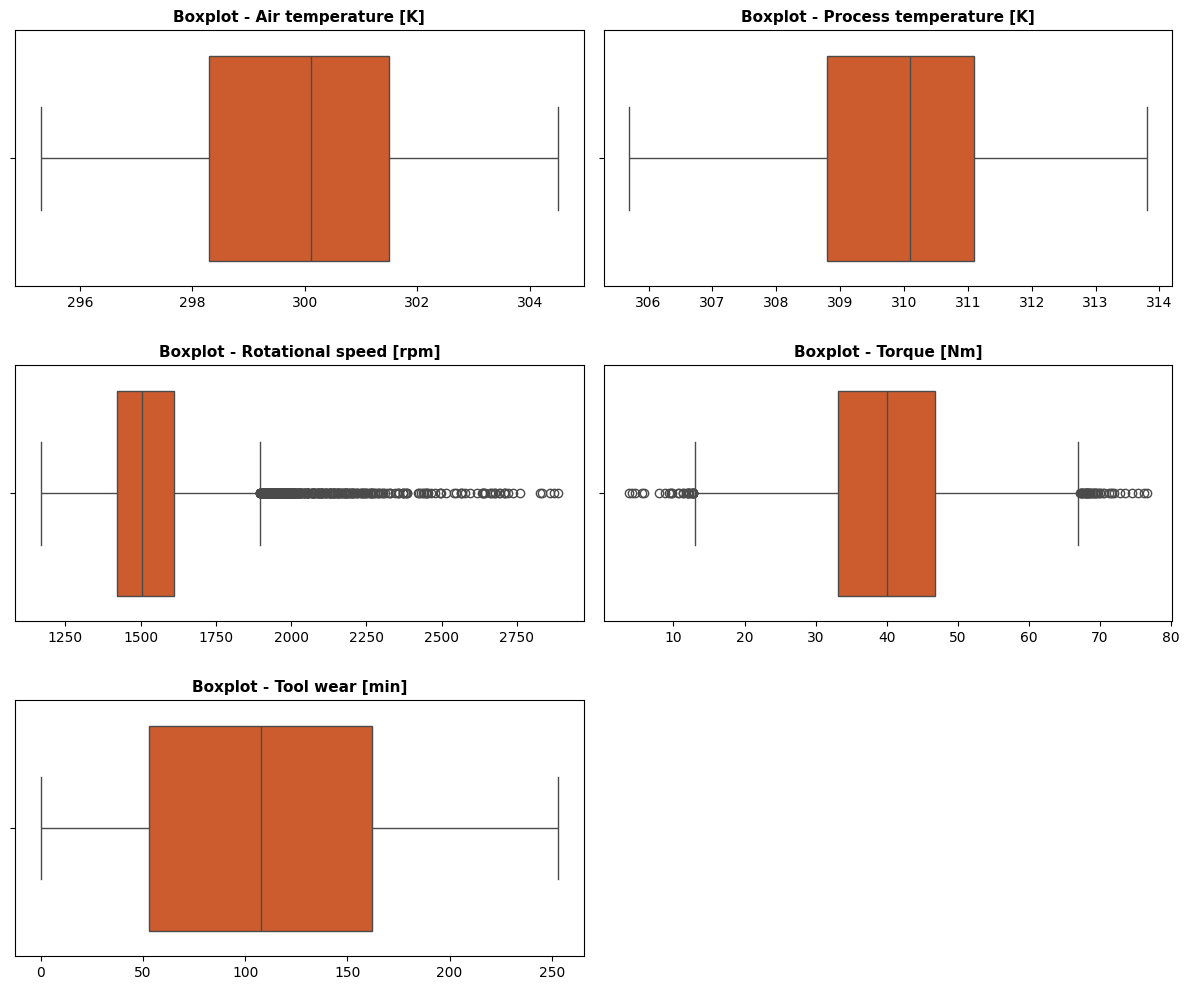

In [ ]:
# =========================================================
# DETECCIÓN DE OUTLIERS (BOXPLOTS)
# =========================================================
plt.figure(figsize=(12, 10))

for i, col in enumerate(sensor_columns):
    plt.subplot(3, 2, i+1)

    sns.boxplot(x=df[col], color="#E65113")

    plt.title(f"Boxplot - {col}", fontsize=11, fontweight='bold')
    plt.xlabel("")

plt.tight_layout(h_pad=2.5)
plt.show()

### Observaciones

**Air temperature [K] y Process temperature [K] (Temperaturas):**

Ambas variables presentan diagramas simétricos, con la mediana ubicada cerca del centro del rango intercuartílico. No se observan valores atípicos fuera de los límites de los bigotes.

Este comportamiento sugiere que las temperaturas registradas se mantienen dentro de rangos estables a lo largo del conjunto de datos. La ausencia de valores extremos indica que no se presentan desviaciones térmicas significativas respecto al comportamiento general de estas variables.

**Rotational speed [rpm] (Velocidad de rotación):**

La caja se concentra entre 1400 y 1600 rpm, lo que indica que el 50% central de las observaciones se encuentra en este intervalo. Sin embargo, se observa gran cantidad de valores atípicos en la parte superior del rango, lo que genera una clara asimetría positiva en la distribución.

Este comportamiento indica que, aunque la mayor parte de las operaciones se realizan dentro de un rango estable de velocidades, existen numerosos registros con velocidades superiores al rango central de operación. La presencia de estos valores extremos sugiere que el sistema experimenta ocasionalmente condiciones de operación a velocidades significativamente más elevadas que el comportamiento típico.

**Torque [Nm] (Fuerza de torsión):**

El diagrama muestra una distribución simétrica centrada en torno a 40 Nm, con una dispersión moderada dentro del rango intercuartílico.

No obstante, se identifican valores atípicos en el extremo inferior y superior de la distribución; indicando que aunque el sistema opera generalmente en torno a un nivel de esfuerzo estable, existen situaciones donde el torque registrado se aleja del comportamiento promedio.

Estos valores extremos podrían asociarse a condiciones operativas particulares o estados de carga no habituales.

**Tool wear [min] (Desgaste de la herramienta):**

El diagrama muestra una dispersión amplia con valores que abarcan aproximadamente desde 50 hasta 160 minutos dentro del rango intercuartílico y una mediana cercana a 110 minutos. No se identifican valores atípicos fuera de los límites establecidos por el diagrama.

Este comportamiento indica que el dataset contiene observaciones correspondientes a herramientas con distintos niveles de uso acumulado. La ausencia de valores extremos sugiere que el desgaste registrado se mantiene dentro de los límites operativos observados en el conjunto de datos.

### **Análisis de correlaciones**
El análisis de correlaciones permite identificar el grado de asociación lineal entre las variables, lo cual resulta útil para detectar posibles redundancias entre variables y explorar qué factores podrían estar relacionados con la ocurrencia de fallos en la máquina.

Para ello se calcula la matriz de correlación de Pearson y se representa mediante un mapa de calor (*heatmap*), que facilita la visualización de las relaciones entre las variables del sistema.

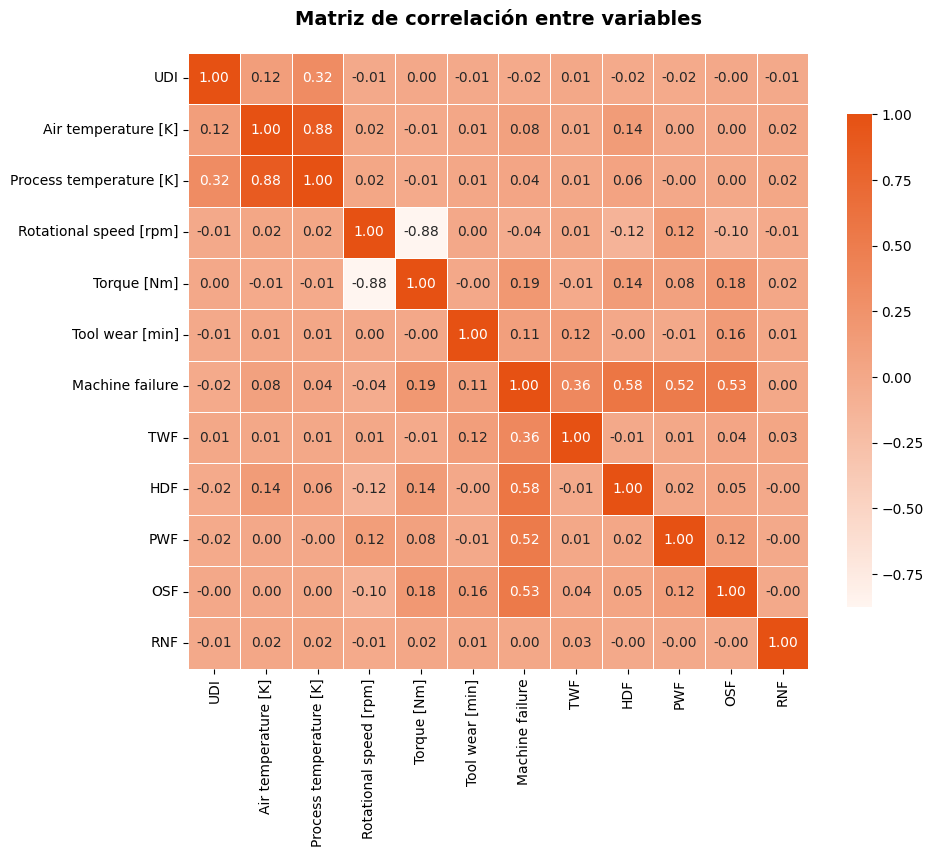

In [ ]:
# =========================================================
# MATRIZ DE CORRELACIÓN
# =========================================================

cmap_naranja = mcolors.LinearSegmentedColormap.from_list("naranja_custom", ["#FFF5F0", "#E65113"])
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=cmap_naranja,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de correlación entre variables", fontsize=14, fontweight='bold', pad=20)
plt.show()

### **Análisis de correlaciones entre variables operativas**
Para este análisis se considera sólo las variables operativas continuas registradas por los sensores de la máquina. Se excluyen las variables identificadoras y las directamente asociadas a los eventos de fallo, con el fin de evitar interpretaciones sesgadas y centrarse únicamente en las relaciones entre las condiciones de operación del sistema.

La matriz de correlación se representa mediante un mapa de calor (*heatmap*), lo que permite visualizar de forma clara el grado de asociación lineal entre las diferentes variables.

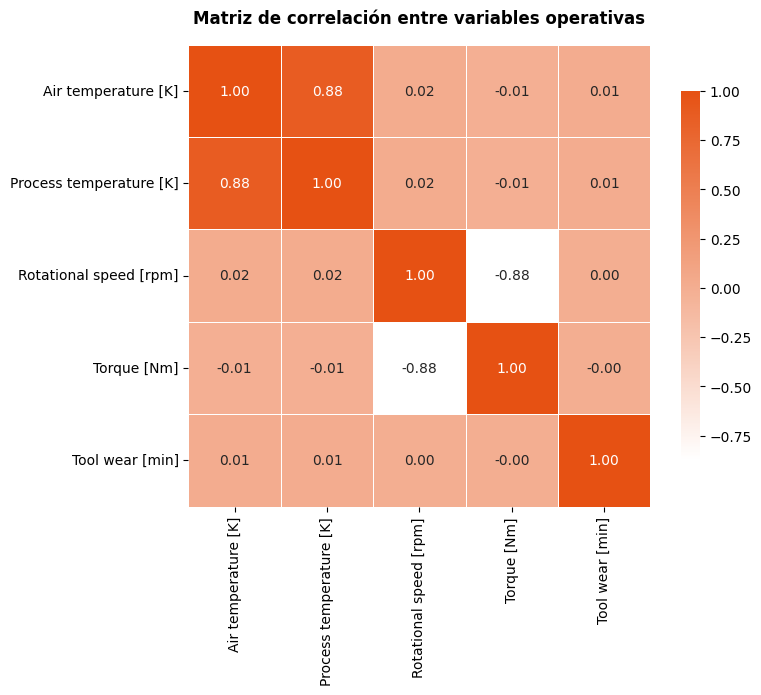

In [ ]:
# =========================================================
# MATRIZ DE CORRELACIÓN ENTRE VARIABLES OPERATIVAS
# =========================================================

cmap_naranja = mcolors.LinearSegmentedColormap.from_list("naranja_custom", ["#FFFFFF", "#E65113"])

corr_matrix_operativas = df[sensor_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix_operativas,
    annot=True,
    cmap=cmap_naranja,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de correlación entre variables operativas", fontsize=12, fontweight='bold', pad=15)
plt.show()

### **Observaciones**
El análisis de correlaciones muestra relaciones destacadas entre las variables operativas.

*   Se observa una correlación positiva elevada entre la temperatura del aire y la temperatura del proceso (≈ 0.88), lo que sugiere que estas variables podrían contener información redundante.
*   Se observa una correlación negativa fuerte entre la velocidad de rotación y el torque (≈ -0.88), lo que indica una relación inversa entre ambas variables mecánicas.
*   La variable de desgaste de la herramienta presenta niveles de correlación muy bajos con el resto de variables, lo que sugiere que aporta información adicional y complementaria sobre el estado operativo del sistema.

En general, la mayoría de las variables muestran correlaciones bajas o moderadas, lo que indica que los sensores capturan dimensiones distintas del funcionamiento de la máquina y constituyen una base adecuada para el desarrollo de modelos predictivos.

### **Comparación de variables operativas según ocurrencia de fallo**
Este análisis permite identificar diferencias en las condiciones de operación entre los registros en los que se produce un fallo y aquellos en los que la máquina funciona con normalidad. La detección de estos patrones resulta especialmente relevante en el contexto del mantenimiento predictivo, ya que permite evaluar si las variables de sensores contienen información útil para anticipar eventos de fallo.

Para ello se comparan las distribuciones de las variables operativas según la variable objetivo *Machine failure*, utilizando diagramas de caja que permiten visualizar diferencias en la mediana, la dispersión y la presencia de valores extremos entre ambos grupos.

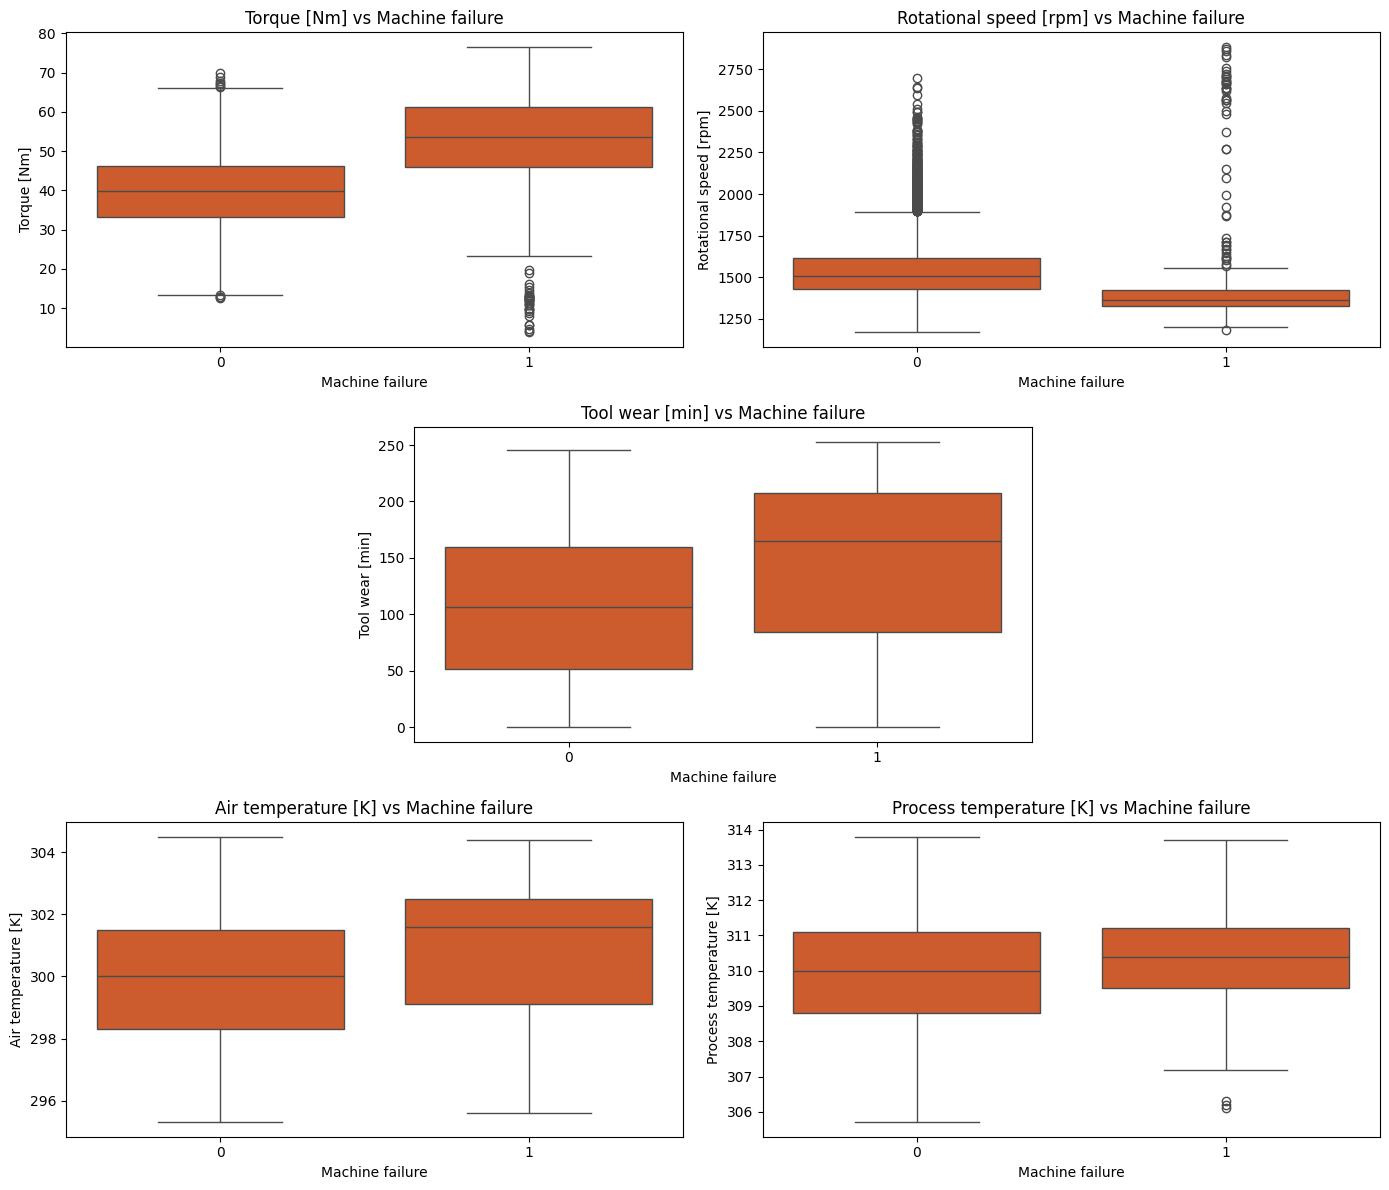

In [ ]:
# =========================================================
# COMPARACIÓN DE SENSORES SEGÚN FALLO (DISEÑO PERSONALIZADO)
# =========================================================

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 4)

color_caja = "#E65113"

# --- VARIABLES MECÁNICAS ---
ax1 = fig.add_subplot(gs[0, 0:2])
sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df, color=color_caja, ax=ax1)
ax1.set_title("Torque [Nm] vs Machine failure")

ax2 = fig.add_subplot(gs[0, 2:4])
sns.boxplot(x="Machine failure", y="Rotational speed [rpm]", data=df, color=color_caja, ax=ax2)
ax2.set_title("Rotational speed [rpm] vs Machine failure")

# --- VARIABLE DE TIEMPO ---
ax3 = fig.add_subplot(gs[1, 1:3])
sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df, color=color_caja, ax=ax3)
ax3.set_title("Tool wear [min] vs Machine failure")

# --- VARIABLES TÉRMICAS ---
ax4 = fig.add_subplot(gs[2, 0:2])
sns.boxplot(x="Machine failure", y="Air temperature [K]", data=df, color=color_caja, ax=ax4)
ax4.set_title("Air temperature [K] vs Machine failure")

ax5 = fig.add_subplot(gs[2, 2:4])
sns.boxplot(x="Machine failure", y="Process temperature [K]", data=df, color=color_caja, ax=ax5)
ax5.set_title("Process temperature [K] vs Machine failure")

plt.tight_layout()
plt.show()

### **Observaciones**

A continuación se detallan los hallazgos más relevantes:

**Torque [Nm]:**
Se observa una diferencia significativa entre los estados:

- En condición normal: el torque presenta una mediana cercana a 40 Nm.
- En condición de fallo: la distribución se desplaza hacia valores más altos,
  con una mediana próxima a 55 Nm. Se identifican valores atípicos en rangos bajos dentro del estado de fallo, lo que sugiere la existencia de múltiples modos de fallo.

El fallo de la máquina no responde a un comportamiento lineal, sino que puede
estar asociado tanto a condiciones de sobrecarga (alto torque) como a
comportamientos anómalos en rangos bajos de torque.

**Rotational speed [rpm]:**
Se observa un comportamiento inverso respecto al torque:

- En estado de fallo, la velocidad de rotación disminuye significativamente.
- Existen valores atípicos elevados en fallos, lo que sugiere comportamientos
  no homogéneos.

Este patrón confirma la relación inversa entre torque y velocidad, y evidencia
que el fallo puede producirse bajo diferentes condiciones operativas.

**Tool wear [min]:**
El desgaste de la herramienta muestra una clara separación entre clases:

- En estado normal, la distribución es amplia.
- En estado de fallo, los valores se concentran en niveles elevados, con una mediana significativamente superior.

El desgaste acumulado es uno de los factores más relevantes en la ocurrencia
de fallos, actuando como indicador clave en el mantenimiento predictivo.

**Temperaturas:**
Las variables de temperatura presentan un alto grado de solapamiento entre
las clases de fallo y no fallo.

- Las diferencias en medianas son mínimas.
- Existe una alta correlación entre la temperatura del aire y la del proceso.

De forma individual, estas variables no presentan un alto poder discriminativo.
Esto sugiere la necesidad de aplicar técnicas de feature engineering para capturar mejor posibles patrones de sobrecalentamiento.

### **Análisis de Resultados: Tasa de Fallo por Tipo de Producto**

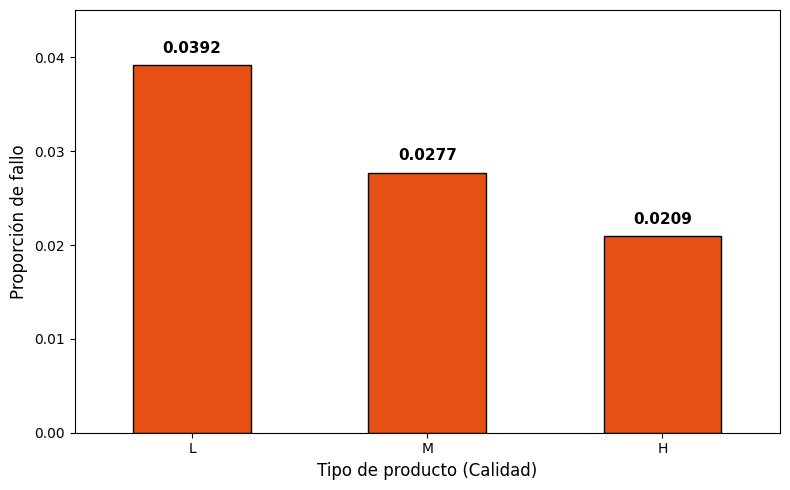

In [ ]:
# =========================================================
# TASA DE FALLO POR TIPO DE PRODUCTO
# =========================================================

failure_rate = df.groupby("Type")["Machine failure"].mean()
failure_rate = failure_rate.reindex(['L', 'M', 'H'])
plt.figure(figsize=(8, 5))

ax = failure_rate.plot(kind="bar", color="#E65113", edgecolor='black')
plt.ylim(0, failure_rate.max() * 1.15)

plt.ylabel("Proporción de fallo", fontsize=12)
plt.xlabel("Tipo de producto (Calidad)", fontsize=12)

plt.xticks(rotation=0)

for i, v in enumerate(failure_rate):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



Al evaluar la proporción de fallos según la variante de calidad del producto **(Type)**, observamos un patrón escalonado que confirma la lógica operativa y física de la maquinaria:

* **Tipo L (Low / Calidad Baja):** Presenta la mayor tasa de vulnerabilidad. Aproximadamente el **3.9%** de las operaciones realizadas con este tipo de producto resultan en un fallo de la máquina.
* **Tipo M (Medium / Calidad Media):** Se sitúa en un punto intermedio, registrando una tasa de avería cercana al **2.8%**.
* **Tipo H (High / Alta Calidad):** Demuestra ser la variante más robusta y confiable para el equipo operativo, es la tasa de fallo más baja con un **2.1%**.

La variable categórica `Type` no es ruido estadístico; posee un alto valor predictivo. Queda en evidencia una relación directa entre la calidad de la variante y el riesgo asociado a la operación (a menor calidad del producto, el riesgo de fallo casi se duplica respecto a la calidad alta). Esta variable aportará una señal muy fuerte al algoritmo de Machine Learning para ajustar sus predicciones de riesgo.

# **INGENIERIA DE CARACTERISTICAS**

En esta etapa, se transforman y enriquecen las variables originales para capturar relaciones físicas complejas que faciliten el aprendizaje del modelo. Basándose en el análisis exploratorio y en el conocimiento del dominio del mantenimiento industrial, se generan tres variables derivadas críticas:

1. **Diferencial Térmico (`Temperature_difference`):** Representa el gradiente de calor entre el proceso y el entorno, factor clave para detectar fallos por disipación térmica.
2. **Potencia Mecánica (`Power`):** Producto del Torque y la Velocidad de rotación. Integra en una sola magnitud el esfuerzo operativo del activo.
3. **Estrés Mecánico (`Mechanical_stress`):** Modela el efecto combinado del par motor y el desgaste acumulado de la herramienta, factores con alta correlación con eventos de fallo catastrófico.

In [ ]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

df["Temperature_difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]

df["Power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]

df["Mechanical_stress"] = df["Torque [Nm]"] * df["Tool wear [min]"]

# **Preparación y preprocesamiento de datos**

## **DEFINICIÓN DE VARIABLES OBJETIVO Y VARIABLES PREDICTORAS**

El análisis previo permitió comprender la naturaleza del problema y definir  *Machine failure* como la **variable objetivo**, ya que indica si se ha producido o no un fallo en la máquina durante el proceso de operación.

Las variables relacionadas con temperaturas, velocidad de rotación, torque y desgaste de herramienta constituyen las **variables predictoras**, ya que describen el estado operativo de la máquina y pueden aportar información relevante para anticipar posibles fallos. Se excluyen del conjunto de variables predictoras los registros *UDI* y *Product ID*, ya que no contienen información relevante para el proceso de aprendizaje del modelo.

In [ ]:
y = df["Machine failure"]
X = df.drop(columns=["Machine failure", "UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])

print("Dimensión de variables predictoras:", X.shape)
print("Dimensión de variable objetivo:", y.shape)

Dimensión de variables predictoras: (10000, 9)
Dimensión de variable objetivo: (10000,)


## **Codificación de variable categórica (Type)**

La variable `Type` es de naturaleza categórica. Para que los algoritmos de aprendizaje automático puedan procesar esta información, se aplica la técnica de **One-Hot Encoding**.

Se emplea el parámetro `drop_first=True` para eliminar la categoría de referencia y evitar problemas de multicolinealidad.

In [ ]:
# =========================================================
# CODIFICACIÓN DE VARIABLE CATEGÓRICA
# =========================================================

X = pd.get_dummies(X, columns=["Type"], drop_first=True)
X = X.astype(int)

print("Columnas después de encoding:")
display(X.head())

Columnas después de encoding:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature_difference,Power,Mechanical_stress,Type_L,Type_M
0,298,308,1551,42,0,10,66382,0,0,1
1,298,308,1408,46,3,10,65190,138,1,0
2,298,308,1498,49,5,10,74001,247,1,0
3,298,308,1433,39,7,10,56603,276,1,0
4,298,308,1408,40,9,10,56320,360,1,0


Como se observa en la tabla superior, el dataset ha sido transformado exitosamente para el modelado:
*   **Codificación:** La columna original `Type` ha desaparecido, siendo sustituida por `Type_L` y `Type_M`. Un valor de `0` en ambas indica que el activo pertenece a la categoría de alta calidad (H).
*   **Formato:** Todos los datos se presentan ahora en formato numérico (enteros), eliminando cualquier ambigüedad para los algoritmos de clasificación supervisada.

## **División y Escalado de Variables**
En esta fase, se prepara el conjunto de datos para el entrenamiento y la validación de los modelos de *Machine Learning*.

### **División Estratificada (Train/Test)**
Se realiza una partición del dataset destinando el **80% para entrenamiento** y el **20% para prueba**. Dado el desbalance de la variable objetivo, se utiliza una **división estratificada** (`stratify=y`). Este procedimiento garantiza que la proporción de fallos y condiciones normales se mantenga constante en ambos subconjuntos, evitando sesgos en la evaluación del rendimiento.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

### **Estandarización de Datos**
Debido a que las variables operativas presentan escalas diversas, se aplica la técnica de **estandarización** mediante `StandardScaler`. El escalado se ajusta únicamente con los datos de entrenamiento para evitar la fuga de información (*data leakage*) hacia el conjunto de prueba.

In [ ]:
# =========================================================
# ESCALADO DE VARIABLES
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Tratamiento del Desbalance de Clases (SMOTE)**
Para mitigar el desbalance de la variable objetivo, se aplica la técnica **SMOTE**. SMOTE crea nuevas instancias sintéticas de fallo mediante la interpolación de características de los vecinos más cercanos en el espacio de variables. Se aplica sobre el conjunto de entrenamiento para garantizar que la evaluación en el conjunto de prueba se mantenga fiel a la realidad operativa de la planta.

In [ ]:
# =========================================================
# BALANCEO DE DATOS CON SMOTE
# =========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Antes de SMOTE:", y_train.value_counts())
print("Después de SMOTE:", pd.Series(y_train_res).value_counts())

Antes de SMOTE: Machine failure
0    7729
1     271
Name: count, dtype: int64
Después de SMOTE: Machine failure
0    7729
1    7729
Name: count, dtype: int64


El conjunto de entrenamiento ha pasado de tener solo 271 ejemplos de fallo a un total de **7,729 instancias por clase**.

## **MODELADO**

### **RANDOM FOREST — ENTRENAMIENTO Y RESULTADOS**
Se elige este algoritmo por su alta resistencia al ruido, su capacidad para manejar variables de diferentes escalas y su robustez frente al sobreajuste.

In [ ]:
# =========================================================
# RANDOM FOREST - MODELO BASE
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED
)

# Entrenamiento
rf_model.fit(X_train_res, y_train_res)

# Predicción
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
# =========================================================
# EVALUACIÓN RANDOM FOREST
# =========================================================

print("ACCURACY:", accuracy_score(y_test, y_pred_rf))
print("\nRECALL:", recall_score(y_test, y_pred_rf))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf))

ACCURACY: 0.978

RECALL: 0.7794117647058824

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.65      0.78      0.71        68

    accuracy                           0.98      2000
   macro avg       0.82      0.88      0.85      2000
weighted avg       0.98      0.98      0.98      2000



**Análisis de Métricas Obtenidas:**
*   **Accuracy (0.978):** El modelo clasifica correctamente el 97.8% de las instancias totales.
*   **Recall - Sensibilidad (0.78):** El modelo es capaz de identificar el **78% de los fallos reales**. Indica una buena capacidad para anticipar averías antes de que ocurran.
*   **Precision (0.65):** Cuando el modelo predice un fallo, tiene un 65% de probabilidad de acierto. El 35% restante corresponde a falsas alarmas, un coste asumible en comparación con el riesgo de un fallo imprevisto.
*   **F1-Score (0.71):** Proporciona un equilibrio sólido entre precisión y sensibilidad para la clase de fallo.

Random Forest demuestra ser un clasificador robusto con una alta capacidad de detección, estableciendo una base sólida para la comparación con modelos de boosting.

#### Análisis Visual: Matriz de Confusión (Random Forest)
Esta herramienta permite visualizar el desempeño del algoritmo comparando los valores reales frente a las predicciones. En el mantenimiento predictivo, nos interesa observar los Falsos Negativos, que representa los fallos no detectados por el sistema.

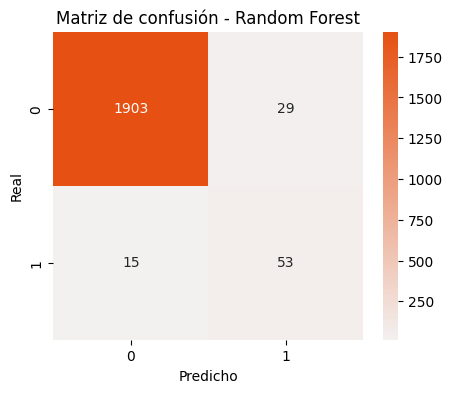

In [ ]:
plt.figure(figsize=(5,4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
mi_paleta = sns.light_palette("#E65113", as_cmap=True)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap=mi_paleta)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

Interpretación de la Matriz:
*   **Verdaderos Positivos (53):** El sistema identificó correctamente 53 eventos de fallo real.
*   **Falsos Negativos (15):** Existen 15 fallos que el modelo no detectó (se clasificaron como operación normal). Reducir este número es la prioridad para evitar paradas catastróficas.
*   **Falsos Positivos (29):** El modelo generó 29 alarmas en momentos donde la máquina operaba normalmente. Esto se traduce en inspecciones preventivas que, aunque no eran urgentes, ayudan a asegurar la salud del activo.
*   **Verdaderos Negativos (1903):** Gran capacidad para reconocer el estado de funcionamiento estable del sistema.

#### Importancia de las Variables (Feature Importance)
Para reducir la opacidad del modelo de "caja negra", se analiza la importancia de las características. Este análisis permite identificar qué variables operativas tienen un mayor peso relativo en la capacidad del modelo para discriminar entre el estado de funcionamiento normal y el riesgo de fallo.

,Variable,Importancia
2,Rotational speed [rpm],0.211972
3,Torque [Nm],0.180414
6,Power,0.169942
4,Tool wear [min],0.128362
7,Mechanical_stress,0.113229
5,Temperature_difference,0.093139
0,Air temperature [K],0.050860
1,Process temperature [K],0.037262
8,Type_L,0.008314
9,Type_M,0.006506


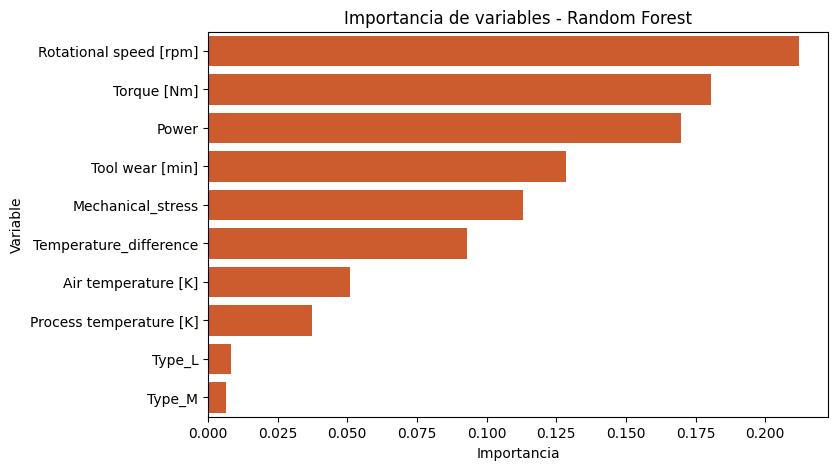

In [ ]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

display(importance_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Importancia",
    y="Variable",
    color="#E65113"
)

plt.title("Importancia de variables - Random Forest")

plt.show()

Interpretación del Resultado:
*   **Dominancia Mecánica:** Rotational speed y Torque se consolidan como los principales precursores de fallo.
*   **Éxito de la Ingeniería de Características:** Power ocupa el tercer lugar en importancia, confirmando que la integración de variables mecánicas facilita la detección de patrones de fallo.
*   **Variables de Desgaste y Estrés:** Tool wear como Mechanical_stress presentan una contribución significativa.
*   **Diferencial Térmico:** Temperature_difference muestra una relevancia superior a las temperaturas absoluta por separado, demostrando que el gradiente térmico es un mejor indicador de anomalías por disipación de calor.

## **GRADIENT BOOSTING — ENTRENAMIENTO Y EVALUACIÓN**

Se implementa **Gradient Boosting**, una técnica de aprendizaje secuencial que construye árboles de forma iterativa, donde cada nuevo árbol corrige los errores residuales de los anteriores.

In [ ]:
# =========================================================
# GRADIENT BOOSTING - MODELO
# =========================================================
gb_model = GradientBoostingClassifier(
    random_state=SEED
)

# Entrenamiento
gb_model.fit(X_train_res, y_train_res)

# Predicción
y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
# =========================================================
# EVALUACIÓN GRADIENT BOOSTING
# =========================================================
print("ACCURACY:", accuracy_score(y_test, y_pred_gb))
print("RECALL:", recall_score(y_test, y_pred_gb))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_gb))

ACCURACY: 0.962
RECALL: 0.8676470588235294

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1932
           1       0.47      0.87      0.61        68

    accuracy                           0.96      2000
   macro avg       0.73      0.92      0.79      2000
weighted avg       0.98      0.96      0.97      2000



**Análisis de los Resultados:**
*   **Recall - Sensibilidad (0.868):** El modelo logra identificar correctamente casi el **87% de los fallos reales**, superando significativamente al modelo Random Forest.
*   **Accuracy (0.962):** Se mantiene una exactitud global muy elevada, lo que garantiza la fiabilidad del sistema.
*   **Precision (0.47):** La caída en la precisión es un compromiso técnico deliberado. Significa que aceptamos un mayor número de "falsas alarmas" a cambio de asegurar que casi ninguna avería pase desapercibida.
*   **F1-Score (0.61):** Representa el equilibrio final alcanzado para la clase crítica.

Gradient Boosting se consolida como mejor opción, ya que prioriza la seguridad operativa y la prevención de fallos catastróficos.

#### Análisis Visual: Matriz de Confusión (GB)

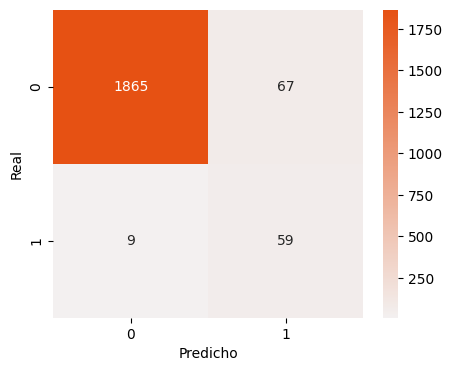

In [ ]:
plt.figure(figsize=(5,4))

cm_gb = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm_gb, annot=True, fmt="d", cmap=mi_paleta)

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

Interpretación de la Matriz
*   **Reducción Crítica de Falsos Negativos (9):** Solo 9 fallos de 68 quedaron sin detectar, logrando una mejora notable frente a los 15 omitidos por Random Forest.
*   **Verdaderos Positivos (59):** El sistema identifica correctamente 59 situaciones de riesgo, permitiendo programar el mantenimiento preventivo de forma oportuna.
*   **Gestión de Falsos Positivos (67):** El incremento en las falsas alarmas (67 frente a 29) es el "coste de seguridad" asumido para proteger los activos crítico.
*   **Fiabilidad en Operación Normal (1865):** El modelo mantiene una precisión excelente al identificar el funcionamiento estable, evitando interrupciones innecesarias en la producción en la mayoría de los casos.

#### Importancia de las Variables (Feature Importance)

,Variable,Importancia
2,Rotational speed [rpm],0.297166
6,Power,0.172185
4,Tool wear [min],0.164312
3,Torque [Nm],0.156201
5,Temperature_difference,0.091472
7,Mechanical_stress,0.084761
1,Process temperature [K],0.016652
0,Air temperature [K],0.014760
8,Type_L,0.002407
9,Type_M,0.000083


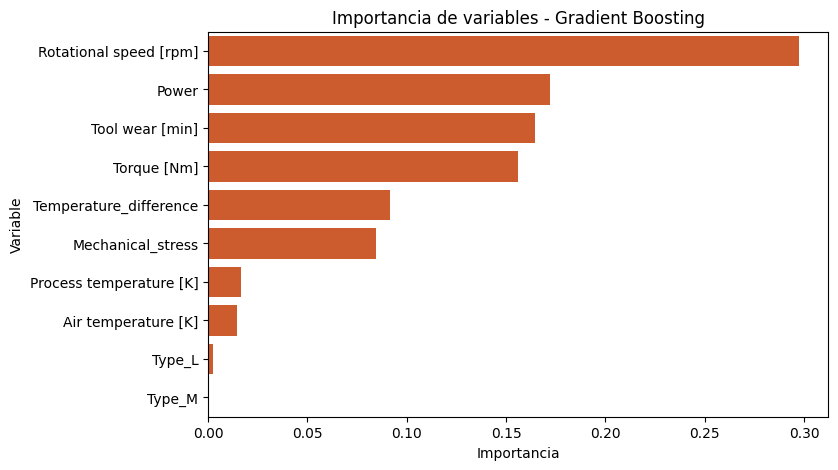

In [ ]:
# =========================================================
# FEATURE IMPORTANCE - GRADIENT BOOSTING
# =========================================================
gb_importances = gb_model.feature_importances_

gb_importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": gb_importances
}).sort_values(by="Importancia", ascending=False)

display(gb_importance_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=gb_importance_df,
    x="Importancia",
    y="Variable",
    color="#E65113"
)

plt.title("Importancia de variables - Gradient Boosting")

plt.show()

Interpretación de Resultados
*   **Poder Predictivo de la Velocidad:** Rotational speed incrementa su relevancia respecto a Random Forest, situándose cerca del **30% del peso total** de la decisión.
*   **Consolidación de Variables Derivadas:** Power se posiciona como la segunda más importante (aprox. 17%). Su alta relevancia, sumada a Mechanical_stress y Temperature_difference, demuestra que el modelo aprovecha mejor las interacciones físicas calculadas que las lecturas crudas de los sensores.
*   **Desgaste de Herramienta:** Tool wear se mantiene en el "Top 3", lo que es coherente con el ciclo de vida de los activos industriales.
*   **Variables de Calidad:** Las variables Type_L y Type_M presentan una importancia residual, lo que sugiere que, si bien la calidad del producto influye, son las condiciones operativas de uso las que determinan de forma dominante el riesgo de fallo.

## **SUPPORT VECTOR MACHINE — ENTRENAMIENTO Y EVALUACIÓN**

A diferencia de los modelos basados en árboles, SVM busca encontrar el hiperplano óptimo que maximiza el margen de separación entre las clases de "Fallo" y "No Fallo". Este modelo es especialmente sensible al escalado de variables realizado previamente mediante StandardScaler.

In [ ]:
# =========================================================
# SUPPORT VECTOR MACHINE (SVM)
# =========================================================
svm_model = SVC(
    probability=True,
    random_state=SEED
)

# Entrenamiento
svm_model.fit(X_train_res, y_train_res)

# Predicción
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
# =========================================================
# EVALUACIÓN SVM
# =========================================================
print("ACCURACY:", accuracy_score(y_test, y_pred_svm))
print("RECALL:", recall_score(y_test, y_pred_svm))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_svm))

ACCURACY: 0.9265
RECALL: 0.8676470588235294

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.30      0.87      0.45        68

    accuracy                           0.93      2000
   macro avg       0.65      0.90      0.70      2000
weighted avg       0.97      0.93      0.94      2000



**Análisis de Resultados (SVM):**
*   **Recall (0.868):** El modelo alcanza una sensibilidad idéntica al modelo GB, identificando correctamente casi el 87% de las averías reales.
*   **Precision (0.30):** Este es el punto crítico de este algoritmo. Una precisión de solo el 30% indica un volumen muy elevado de falsos positivos (falsas alarmas), superando significativamente al GB (47%) y al RF (65%).
*   **Accuracy (0.927):** Es la exactitud más baja de los tres modelos evaluados, debido a la dificultad del hiperplano para separar las clases sin incurrir en errores de clasificación de la clase mayoritaria.
*   **F1-Score (0.45):** El bajo valor de esta métrica refleja un desequilibrio importante entre la sensibilidad y la precisión.

Aunque SVM demuestra una alta capacidad de detección, el elevado número de falsas alarmas penalizaría la eficiencia operativa de la planta, provocando demasiadas paradas innecesarias. Esto refuerza la decisión de utilizar modelos basados en ensambles de árboles para el sistema final.

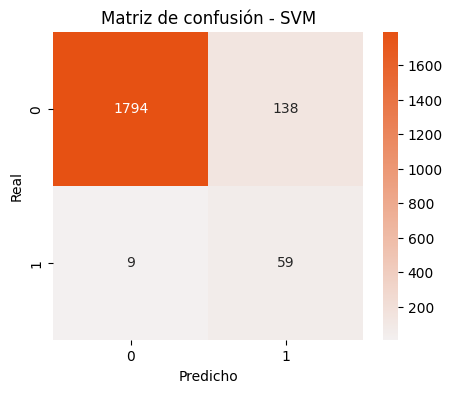

In [ ]:
plt.figure(figsize=(5,4))

cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt="d", cmap=mi_paleta)

plt.title("Matriz de confusión - SVM")
plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

#### Análisis Visual: Matriz de Confusión (SVM)

Interpretación de la Matriz (SVM):
*   **Verdaderos Positivos (59) y Falsos Negativos (9):** El modelo iguala la capacidad de detección de GB, capturando 59 fallos y omitiendo solo 9.
*   **Falsos Positivos (138):** Mientras que GB generaba 67 falsas alarmas, SVM las duplica hasta alcanzar las 138.
*   **Impacto Operativo:** Un exceso de falsos positivos de esta magnitud saturaría al equipo de mantenimiento con inspecciones innecesarias, restando credibilidad al sistema de recomendación y aumentando los costes de mano de obra y paradas técnicas no justificadas.

La matriz confirma que SVM es un modelo alarmista para la planta industrial. Por lo tanto, se descarta en favor de **GB**, que ofrece el mismo nivel de seguridad (Recall) con casi la mitad de falsas alarmas.

## **XGBOOST — ENTRENAMIENTO Y EVALUACIÓN**

Esta técnica tiene capacidad para manejar datos desbalanceados, robustez ante valores atípicos y el uso de regularización interna que ayuda a prevenir el sobreajuste (overfitting).

In [ ]:
# =========================================================
# MODELO XGBOOST BASE
# =========================================================
xgb_base = XGBClassifier(
    random_state=SEED,
    eval_metric='logloss'
)

# Entrenamiento
xgb_base.fit(X_train_res, y_train_res)

# Predicción
y_pred_xgb = xgb_base.predict(X_test_scaled)
y_prob_xgb = xgb_base.predict_proba(X_test_scaled)[:,1]

In [ ]:
# =========================================================
# MÉTRICAS XGBOOST BASE
# =========================================================

print("ACCURACY:", accuracy_score(y_test, y_pred_xgb))
print("RECALL:", recall_score(y_test, y_pred_xgb))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_xgb))

ACCURACY: 0.9835
RECALL: 0.75

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.76      0.75      0.76        68

    accuracy                           0.98      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.98      0.98      0.98      2000



**Análisis de Resultados (XGBoost Base):**

*   **Accuracy (0.984):** Este modelo alcanza la exactitud más alta de todos los algoritmos evaluados.
*   **Recall (0.750):** El modelo identifica correctamente el 75% de las averías reales.
*   **Precision (0.76):** Presenta una precisión alta (76%). Esto indica una reducción significativa de falsos positivos, lo que se traduce en una mayor confiabilidad de las alertas generadas por el sistema.
*   **F1-Score (0.76):** Este valor confirma un comportamiento altamente equilibrado entre la sensibilidad y la precisión, superando el desbalance observado en los modelos previos.

El desempeño global de XGBoost destaca por su capacidad de generalización y robustez. Aunque sacrifica un margen pequeño de sensibilidad en comparación con SVM, el balance obtenido minimiza el impacto operativo de las falsas alarmas.

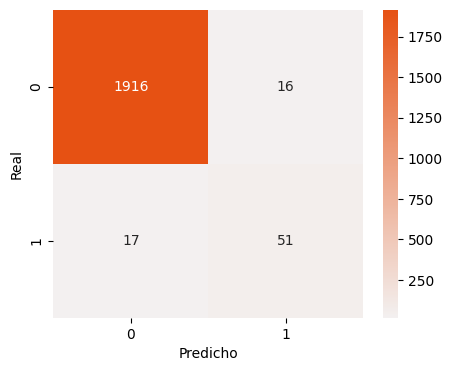

In [ ]:
# =========================================================
# MATRIZ DE CONFUSIÓN XGBOOST BASE
# =========================================================
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap=mi_paleta)

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

#### Análisis Visual: Matriz de Confusión (SVM)
*   **Verdaderos Positivos (51) y Falsos Negativos (17):** El modelo logra identificar 51 fallos reales, aunque omite 17 casos.

*   **Falsos Positivos (16):** Este es el punto de mayor ventaja competitiva. Mientras que SVM generaba 138 falsas alarmas y Gradient Boosting 67, XGBoost las reduce drásticamente a solo 16.

*   **Impacto Operativo:** La reducción drástica de falsos positivos minimiza las inspecciones innecesarias y evita paradas de planta injustificadas.

La matriz confirma que XGBoost ofrece el perfil más equilibrado para la planta industrial.

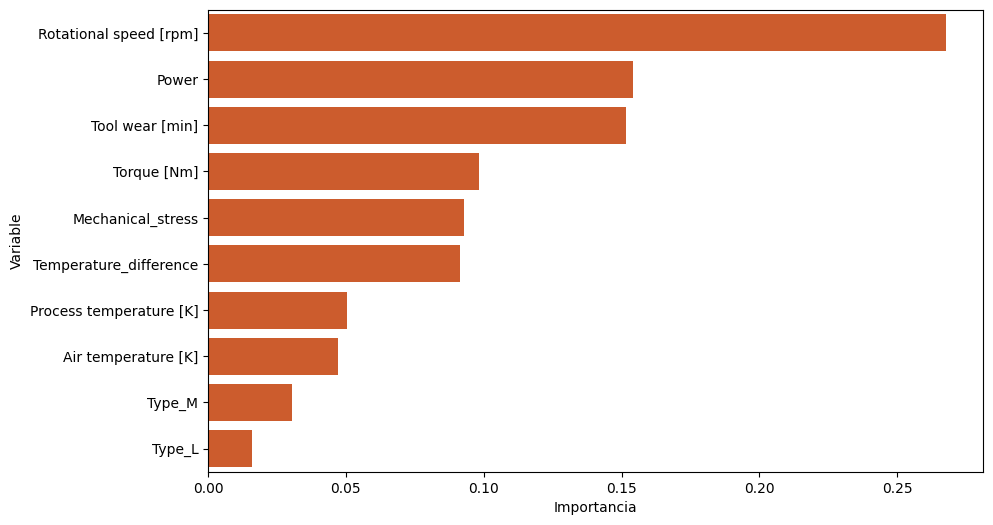

In [ ]:
# =========================================================
# FEATURE IMPORTANCE - XGBOOST BASE
# =========================================================
feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb_base.feature_importances_
}).sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importancia",
    y="Variable",
    color="#E65113"
)

plt.show()

Interpretación de Resultados
*   **Dominio de la Dinámica Operativa:** Rotational speed se consolida como el factor crítico, acumulando cerca del 30% del peso total en la toma de decisiones del modelo.

*   **Eficacia de la Ingeniería de Características:** La segunda variable más relevante es Power (~17%), la cual es una variable derivada,es decir el modelo aprovecha de manera efectiva las interacciones físicas calculadas que las lecturas crudas de los sensores.

*   **Ciclo de Vida del Activo:** El Tool wear [min] se mantiene en el "Top 3", lo cual es plenamente coherente con la realidad industrial, donde el desgaste acumulado es un indicador directo del riesgo de avería.

Como muestra la gráfica, la estructura jerárquica de importancia confirma que el modelo ha aprendido a priorizar el comportamiento dinámico y el desgaste térmico-mecánico de la maquinaria para realizar sus predicciones.

# **OPTIMIZACIÓN DE HIPERPARÁMETROS**

El objetivo es superar los resultados base mediante una búsqueda sistemática de parámetros.

## **RANDOM FOREST - OPTIMIZACIÓN DE HIPERPARÁMETROS**

Se aplica RandomizedSearchCV para explorar de manera eficiente el espacio de hiperparámetros.
*   Parámetros clave: Se ajustan la profundidad de los árboles (max_depth), la cantidad de estimadores (n_estimators) y los criterios de división de nodos (min_samples_split/leaf).
*   Métrica objetivo: Se prioriza el Recall para maximizar la identificación de fallos reales.
*   Validación: Se utiliza una validación cruzada (K=3) sobre los datos balanceados para asegurar la estabilidad del modelo.

In [ ]:
# ---------------------------------------------------------
# ESPACIO DE HIPERPARÁMETROS
# ---------------------------------------------------------

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# ---------------------------------------------------------
# MODELO BASE
# ---------------------------------------------------------

rf_base = RandomForestClassifier(
    random_state=SEED
)

# ---------------------------------------------------------
# RANDOM SEARCH
# ---------------------------------------------------------

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

# ---------------------------------------------------------
# ENTRENAMIENTO
# ---------------------------------------------------------

rf_random.fit(X_train_res, y_train_res)

# ---------------------------------------------------------
# MEJOR MODELO
# ---------------------------------------------------------

best_rf = rf_random.best_estimator_

print("Mejores hiperparámetros:")
print(rf_random.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores hiperparámetros:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


*   Estructura de los Árboles: El valor max_depth: None junto con los mínimos de división (split: 2, leaf: 1) indican que el modelo rinde mejor permitiendo que los árboles crezcan hasta su máxima expansión, lo que facilita la detección de patrones sutiles en la clase minoritaria.

*   Diversidad del Ensamble: El uso de max_features: 'log2' y n_estimators: 200 sugiere que una mayor aleatoriedad en la selección de variables y un bosque más denso ayudan a estabilizar las predicciones, reduciendo la varianza que suele acompañar a los árboles profundos.

*   Resultado: Esta combinación es la que mejor optimiza el Recall sobre el conjunto de validación, preparándonos para evaluar su capacidad de generalización en el set de prueba.

In [ ]:
# =========================================================
# PREDICCIÓN RANDOM FOREST OPTIMIZADO
# =========================================================

y_pred_rf_opt = best_rf.predict(X_test_scaled)
y_prob_rf_opt = best_rf.predict_proba(X_test_scaled)[:,1]

In [ ]:
# =========================================================
# MÉTRICAS RANDOM FOREST OPTIMIZADO
# =========================================================
print("ACCURACY:", accuracy_score(y_test, y_pred_rf_opt))
print("RECALL:", recall_score(y_test, y_pred_rf_opt))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf_opt))

ACCURACY: 0.978
RECALL: 0.7794117647058824

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.65      0.78      0.71        68

    accuracy                           0.98      2000
   macro avg       0.82      0.88      0.85      2000
weighted avg       0.98      0.98      0.98      2000



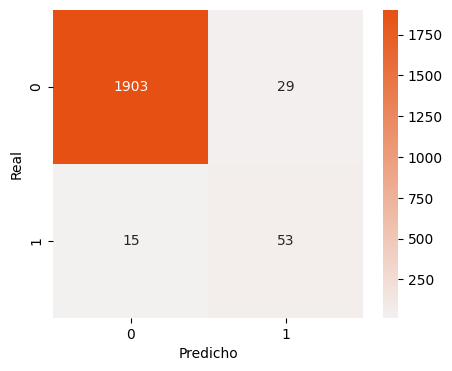

In [ ]:
# =========================================================
# MATRIZ DE CONFUSIÓN RF OPTIMIZADO
# =========================================================
cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)

plt.figure(figsize=(5,4))

sns.heatmap(cm_rf_opt, annot=True, fmt="d", cmap=mi_paleta)

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

In [ ]:
print(rf_random.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


## **GRADIENT BOOSTING - OPTIMIZACIÓN DE HIPERPARÁMETROS**

Se realiza un ajuste fino del modelo Gradient Boosting mediante RandomizedSearchCV.
*   Ejes de ajuste: Se exploran la tasa de aprendizaje (learning_rate) y el número de estimadores (n_estimators) para controlar la velocidad de convergencia, junto con el parámetro subsample para introducir estocasticidad y reducir el sobreajuste.
*   Objetivo: Se prioriza el Recall para asegurar que el modelo optimizado sea altamente eficaz en la detección de paradas no programadas.
*   Validación: Se emplea una validación cruzada (K=3) sobre el conjunto de entrenamiento balanceado.

In [ ]:
# ---------------------------------------------------------
# ESPACIO DE HIPERPARÁMETROS
# ---------------------------------------------------------

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# ---------------------------------------------------------
# MODELO BASE
# ---------------------------------------------------------

gb_base = GradientBoostingClassifier(
    random_state=SEED
)

# ---------------------------------------------------------
# RANDOM SEARCH
# ---------------------------------------------------------

gb_random = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=gb_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

# ---------------------------------------------------------
# ENTRENAMIENTO
# ---------------------------------------------------------

gb_random.fit(X_train_res, y_train_res)

# ---------------------------------------------------------
# MEJORES HIPERPARÁMETROS
# ---------------------------------------------------------

print("Mejores hiperparámetros:")
print(gb_random.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores hiperparámetros:
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}


In [ ]:
# =========================================================
# MEJOR MODELO GB
# =========================================================

best_gb = gb_random.best_estimator_

In [ ]:
# =========================================================
# PREDICCIÓN GB OPTIMIZADO
# =========================================================

y_pred_gb_opt = best_gb.predict(X_test_scaled)
y_prob_gb_opt = best_gb.predict_proba(X_test_scaled)[:,1]

In [ ]:
# =========================================================
# MÉTRICAS GB OPTIMIZADO
# =========================================================

print("ACCURACY:", accuracy_score(y_test, y_pred_gb_opt))
print("RECALL:", recall_score(y_test, y_pred_gb_opt))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_gb_opt))

ACCURACY: 0.98
RECALL: 0.75

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.69      0.75      0.72        68

    accuracy                           0.98      2000
   macro avg       0.84      0.87      0.85      2000
weighted avg       0.98      0.98      0.98      2000



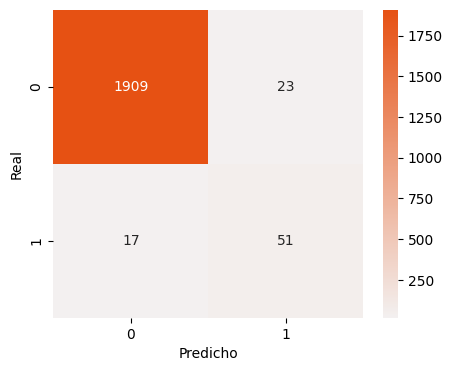

In [ ]:
# =========================================================
# MATRIZ DE CONFUSIÓN GB OPTIMIZADO
# =========================================================

cm_gb_opt = confusion_matrix(y_test, y_pred_gb_opt)

plt.figure(figsize=(5,4))

sns.heatmap(cm_gb_opt, annot=True, fmt="d", cmap=mi_paleta)

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

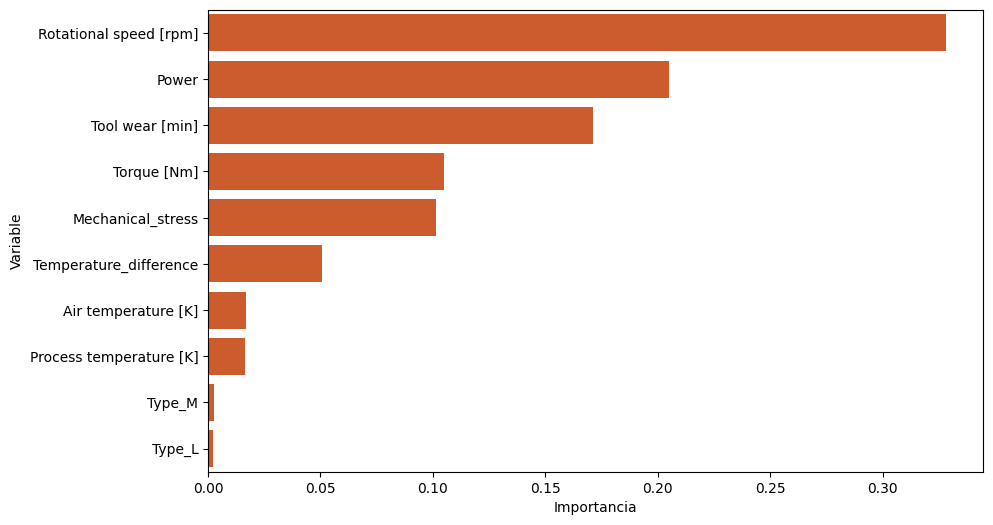

In [ ]:
# =========================================================
# IMPORTANCIA DE VARIABLES - GB OPTIMIZADO
# =========================================================

feature_importance_gb = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': best_gb.feature_importances_
})

feature_importance_gb = feature_importance_gb.sort_values(
    by='Importancia',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_gb,
    x='Importancia',
    y='Variable',
    color="#E65113"
)

plt.show()

## **SVM - OPTIMIZACIÓN DE HIPERPARÁMETROS**

*   Parámetros clave: Se explora el parámetro de regularización C (equilibrio entre margen y error), diferentes funciones de kernel para capturar relaciones no lineales y el coeficiente gamma, que define el alcance de la influencia de cada punto de entrenamiento.
*   Métrica objetivo: Se mantiene el enfoque en el Recall para asegurar que la capacidad de detección de fallos no se pierda durante el ajuste del margen.
*   Proceso: Uso de RandomizedSearchCV con validación cruzada (K=3) para encontrar una configuración competitiva frente a los modelos basados en árboles.

In [ ]:
# ---------------------------------------------------------
# ESPACIO DE HIPERPARÁMETROS
# ---------------------------------------------------------

svm_params = {
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'degree': [2, 3, 4]
}

# ---------------------------------------------------------
# MODELO BASE
# ---------------------------------------------------------

svm_base = SVC(
    probability=False,
    random_state=SEED
)

# ---------------------------------------------------------
# RANDOM SEARCH
# ---------------------------------------------------------

svm_random = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=svm_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

# ---------------------------------------------------------
# ENTRENAMIENTO
# ---------------------------------------------------------

svm_random.fit(X_train_res, y_train_res)

# ---------------------------------------------------------
# MEJORES HIPERPARÁMETROS
# ---------------------------------------------------------

print("Mejores hiperparámetros:")
print(svm_random.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores hiperparámetros:
{'kernel': 'rbf', 'gamma': 'auto', 'degree': 4, 'C': 50}


In [ ]:
# =========================================================
# MEJOR MODELO SVM
# =========================================================

best_svm = svm_random.best_estimator_

In [ ]:
# =========================================================
# PREDICCIÓN SVM OPTIMIZADO
# =========================================================

y_pred_svm_opt = best_svm.predict(X_test_scaled)

In [ ]:
# =========================================================
# MÉTRICAS SVM OPTIMIZADO
# =========================================================
print("ACCURACY:", accuracy_score(y_test, y_pred_svm_opt))
print("RECALL:", recall_score(y_test, y_pred_svm_opt))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_svm_opt))

ACCURACY: 0.959
RECALL: 0.7647058823529411

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.44      0.76      0.56        68

    accuracy                           0.96      2000
   macro avg       0.72      0.87      0.77      2000
weighted avg       0.97      0.96      0.96      2000



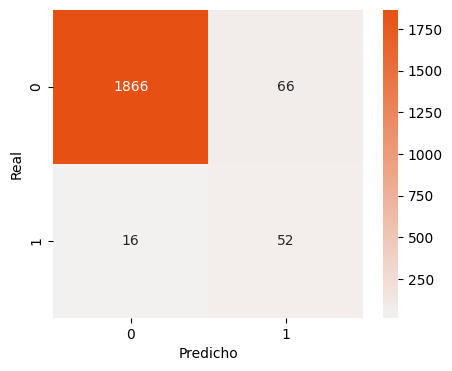

In [ ]:
# =========================================================
# MATRIZ DE CONFUSIÓN SVM OPTIMIZADO
# =========================================================
cm_svm_opt = confusion_matrix(y_test, y_pred_svm_opt)

plt.figure(figsize=(5,4))

sns.heatmap(cm_svm_opt, annot=True, fmt="d", cmap=mi_paleta)

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

# **XGBOST - OPTIMIZACIÓN DE HIPERPARÁMETROS**

*   Parámetros de Estructura y Aprendizaje: Se exploran combinaciones de max_depth y min_child_weight para controlar la complejidad de los árboles, junto con el learning_rate para regular el ritmo de actualización de los pesos.
*   Estrategias de Muestreo: Se ajustan subsample y colsample_bytree para introducir aleatoriedad a nivel de filas y columnas, lo que ayuda a reducir el sobreajuste y mejorar la robustez ante ruido en los sensores.
*   Configuración: Se utiliza RandomizedSearchCV con 20 iteraciones y validación cruzada (K=3), manteniendo el Recall como métrica de optimización prioritaria.

In [ ]:
# =========================================================
# ESPACIO DE HIPERPARÁMETROS
# =========================================================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [ ]:
xgb_base = XGBClassifier(
    random_state=SEED,
    eval_metric='logloss'
)

In [ ]:
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_params,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

# Entrenamiento
xgb_random.fit(X_train_res, y_train_res)

# Mejores parámetros
print("Mejores hiperparámetros:")
print(xgb_random.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores hiperparámetros:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [ ]:
best_xgb = xgb_random.best_estimator_

In [ ]:
y_pred_xgb_opt = best_xgb.predict(X_test_scaled)
y_prob_xgb_opt = best_xgb.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("ACCURACY:", accuracy_score(y_test, y_pred_xgb_opt))
print("RECALL:", recall_score(y_test, y_pred_xgb_opt))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_xgb_opt))

ACCURACY: 0.9835
RECALL: 0.75

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.76      0.75      0.76        68

    accuracy                           0.98      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.98      0.98      0.98      2000



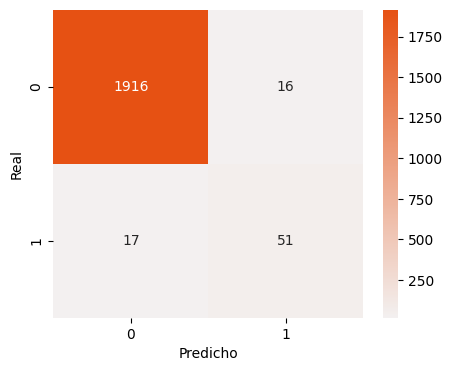

In [ ]:

cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)

plt.figure(figsize=(5,4))

sns.heatmap(cm_xgb_opt, annot=True, fmt="d", cmap=mi_paleta)

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

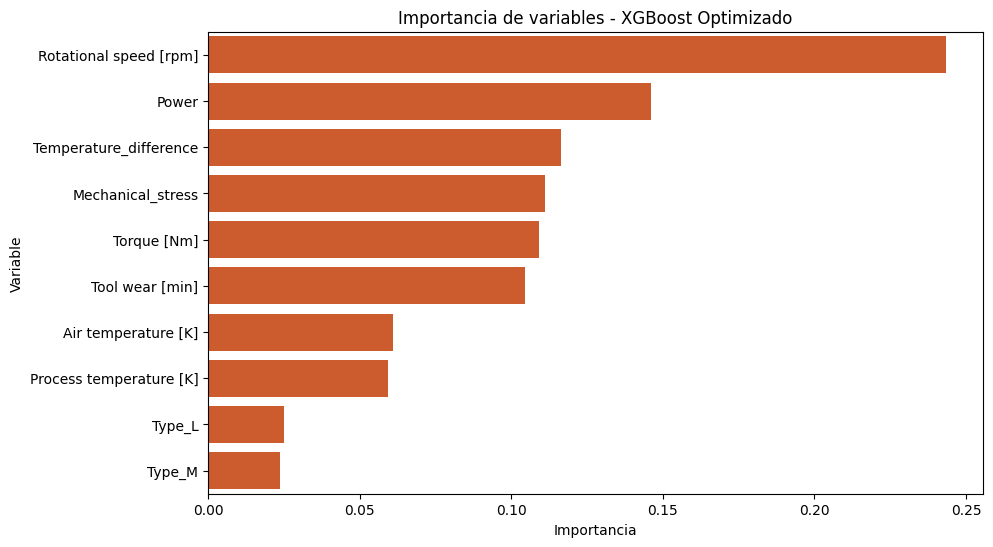

In [ ]:
feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": best_xgb.feature_importances_
}).sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importancia",
    y="Variable",
    color="#E65113"
)

plt.title("Importancia de variables - XGBoost Optimizado")
plt.show()

<Figure size 1200x800 with 0 Axes>

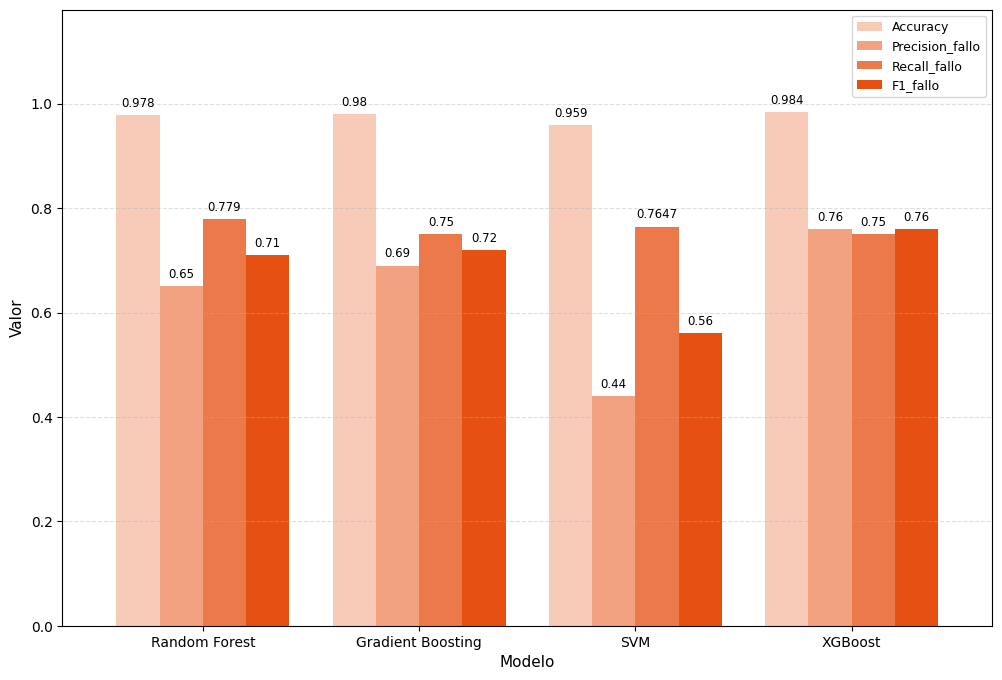

In [ ]:
# =========================================================
# GRÁFICO DE COMPARACIÓN
# =========================================================
color_naranja = '#E65113'
cmap_naranja = mcolors.LinearSegmentedColormap.from_list("naranja_viu", ["#FFFFFF", color_naranja])

# Datos de comparación
results = pd.DataFrame({
    "Modelo": ["Random Forest", "Gradient Boosting", "SVM", "XGBoost"],
    "Accuracy": [0.978, 0.98, 0.959, 0.984],
    "Precision_fallo": [0.65, 0.69, 0.44, 0.76],
    "Recall_fallo": [0.779, 0.75, 0.7647, 0.75],
    "F1_fallo": [0.71, 0.72, 0.56, 0.76]
})

results = results.set_index("Modelo")

# Configuración de la gráfica
plt.figure(figsize=(12, 8))
num_metrics = len(results.columns)
colors_for_plot = [cmap_naranja(i) for i in np.linspace(0.3, 1.0, num_metrics)]

ax = results.plot(kind="bar", figsize=(12, 8), color=colors_for_plot, width=0.8)

plt.ylabel("Valor", fontsize=11)
plt.xlabel("Modelo", fontsize=11)
plt.ylim(0, 1.18)
plt.xticks(rotation=0, fontsize=10)

for container in ax.containers:
    labels = [f'{val:g}' for val in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        label_type='edge',
        padding=4,
        fontsize=8.5
    )

# Leyenda
plt.legend(loc="upper right", fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

Tras la evaluación comparativa de los distintos modelos de aprendizaje automático, se selecciona el modelo XGBoost como modelo final del sistema. Aunque el modelo Random Forest presenta un recall ligeramente superior, XGBoost ofrece un mejor equilibrio entre rendimiento global, estabilidad y capacidad de generalización. Además, su estructura basada en boosting secuencial lo convierte en una opción más robusta para su integración en sistemas de soporte a la decisión.

## **Interpretabilidad del Modelo (SHAP - Explainable AI)**
Se implementa SHAP una técnica que asigna a cada característica un valor de importancia para una predicción específica.

Este análisis permite:

- Explicabilidad Global: Entender qué variables dominan el comportamiento general del modelo.

- Explicabilidad Local: Identificar qué sensores específicos dispararon una recomendación de mantenimiento para una máquina en particular.

In [ ]:
# =========================================================
# EXPLICADOR SHAP PARA XGBOOST
# =========================================================

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test_scaled)

# En clasificación binaria, nos quedamos con la clase positiva (fallo)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("Valores SHAP calculados correctamente con XGBoost.")

Valores SHAP calculados correctamente con XGBoost.


## **Consolidación del Dataset para el Dashboard (DSS)**
Se procede a consolidar los resultados en un dataset estructurado para su integración en Power BI.

In [ ]:
df_dashboard = pd.DataFrame(X_test, columns=X.columns)

df_dashboard['ID'] = range(len(df_dashboard))

print(f"Dataset creado con {df_dashboard.shape[0]} registros.")
display(df_dashboard.head())

Dataset creado con 2000 registros.


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature_difference,Power,Mechanical_stress,Type_L,Type_M,ID
2997,300,309,1345,62,153,9,84331,9593,1,0,0
4871,303,312,1513,40,135,8,60671,5413,1,0,1
3858,302,311,1559,37,209,8,58618,7858,1,0,2
951,295,306,1509,35,60,10,54022,2148,0,0,3
6463,300,310,1358,60,102,9,82023,6160,0,0,4


## **Enriquecimiento del Dataset con Inferencias del Modelo**
Para que el Dashboard sea operativo, es necesario inyectar los resultados del modelo de **XGB** en nuestro dataset de visualización. Se incorporan dos métricas clave:

1.  **Failure_Prediction:** Clasificación binaria que indica si el sistema recomienda una intervención inmediata (1) o si la máquina opera en parámetros normales (0).
2.  **Failure_Probability:** Una métrica continua entre 0 y 1 que cuantifica el nivel de riesgo.

In [ ]:
# =========================================================
# INTEGRACIÓN DE PREDICCIONES Y PROBABILIDADES
# =========================================================

df_dashboard['Failure_Prediction'] = best_xgb.predict(X_test_scaled)

df_dashboard['Failure_Probability'] = best_xgb.predict_proba(X_test_scaled)[:, 1]

display(df_dashboard[['ID', 'Failure_Prediction', 'Failure_Probability']].head())

,ID,Failure_Prediction,Failure_Probability
2997,0,0,0.037132
4871,1,0,0.000146
3858,2,0,0.050413
951,3,0,0.000516
6463,4,0,0.008358


## **Integración de Explicabilidad Local (SHAP Values)**
Para transformar el modelo de una "caja negra" a un sistema transparente y auditable, se incorporan los **Valores SHAP** de las características más influyentes al dataset final.

Cada columna SHAP_ añadida representa la contribución de esa variable específica a la probabilidad de fallo calculada. Esto permitirá que, en el Dashboard final, el usuario pueda visualizar un gráfico de barras explicativo para cada alerta, identificando exactamente si el riesgo se debe a un exceso de velocidad, un sobreesfuerzo mecánico o un desgaste crítico de la herramienta.

In [ ]:
# =========================================================
# EXTRACCIÓN DE CONTRIBUCIONES INDIVIDUALES (XAI)
# =========================================================

df_dashboard['SHAP_Rotational_speed'] = shap_values[:, list(X.columns).index('Rotational speed [rpm]')]
df_dashboard['SHAP_Power'] = shap_values[:, list(X.columns).index('Power')]
df_dashboard['SHAP_Tool_wear'] = shap_values[:, list(X.columns).index('Tool wear [min]')]
df_dashboard['SHAP_Temperature_difference'] = shap_values[:, list(X.columns).index('Temperature_difference')]

print("Explicabilidad local integrada con XGBoost.")

Explicabilidad local integrada con XGBoost.


## **Lógica de Diagnóstico Automatizado (Análisis Causa-Raíz)**
Para que el Sistema DSS sea realmente accionable, se implementa una lógica de **análisis causa-raíz automatizada**.

Se define la columna Key_factor, la cual identifica automáticamente cuál de las variables operativas ha tenido el mayor impacto absoluto en la probabilidad de fallo para cada registro individual.

In [ ]:
# =========================================================
# GENERACIÓN DEL FACTOR CLAVE (DIAGNÓSTICO DIRECTO)
# =========================================================

def causa_principal(row):
    impactos = {
        'Velocidad': abs(row['SHAP_Rotational_speed']),
        'Potencia': abs(row['SHAP_Power']),
        'Desgaste': abs(row['SHAP_Tool_wear']),
        'Temperatura': abs(row['SHAP_Temperature_difference'])
    }
    return max(impactos, key=impactos.get)

df_dashboard['Key_factor'] = df_dashboard.apply(causa_principal, axis=1)

display(df_dashboard[['ID', 'Key_factor']].head())

,ID,Key_factor
2997,0,Temperatura
4871,1,Velocidad
3858,2,Desgaste
951,3,Desgaste
6463,4,Temperatura


## **Segmentación Operativa de Riesgos**
Para facilitar la toma de decisiones rápida se traduce la probabilidad continua del modelo en niveles de riesgo categóricos. Esta segmentación permite establecer protocolos de actuación diferenciados: el riesgo "Alto" dispara una orden de trabajo inmediata, mientras que el "Medio" sugiere una inspección programada para el próximo turno.

In [ ]:
# =========================================================
# CLASIFICACIÓN DE NIVELES DE RIESGO OPERATIVO
# =========================================================

def nivel_riesgo(prob):
    if prob < 0.3:
        return "Bajo"
    elif prob < 0.6:
        return "Medio"
    else:
        return "Alto"

df_dashboard['Risk_level'] = df_dashboard['Failure_Probability'].apply(nivel_riesgo)

print(df_dashboard['Risk_level'].value_counts())

Risk_level
Bajo     1921
Alto       64
Medio      15
Name: count, dtype: int64


## **Sistema de Recomendación Prescriptivo**
La etapa final del motor de inferencia consiste en transformar los niveles de riesgo en acciones concretas de mantenimiento. Esta lógica permite que el Dashboard funcione como un asesor experto, estandarizando la respuesta operativa ante diferentes niveles de probabilidad de fallo y optimizando el uso de recursos técnicos.

In [ ]:
# =========================================================
# LÓGICA DE ACCIÓN PRESCRIPTIVA
# =========================================================
def recomendar_accion(prob):
    if prob < 0.3:
        return "Operación normal"
    elif prob < 0.6:
        return "Mantenimiento preventivo programado"
    else:
        return "Intervención inmediata"

df_dashboard['Maintenance_Recommendation'] = df_dashboard['Failure_Probability'].apply(recomendar_accion)

## **Personalización de Instrucciones Técnicas**
Para maximizar la eficiencia en la planta, el sistema genera una hoja de ruta técnica personalizada para cada registro. Esta lógica combina la severidad del riesgo con el análisis de importancia de variables (SHAP), permitiendo que el mensaje recibido por el operario sea específico al problema detectado.

In [ ]:
# =========================================================
# GENERACIÓN DE INSTRUCCIONES TÉCNICAS ESPECÍFICAS
# =========================================================
def accion_sugerida(row):
    if row['Risk_level'] == "Bajo":
        return "Monitoreo rutinario"
    elif row['Risk_level'] == "Medio":
        return f"Revisar {row['Key_factor']}"
    else:
        return f"Acción crítica sobre {row['Key_factor']}"

df_dashboard['Suggested_Action'] = df_dashboard.apply(accion_sugerida, axis=1)

## **Exportación y Entrega de Resultados**
El paso final es la generación del archivo de datos que servirá de base para el Dashboard de Mantenimiento Predictivo.

Se utiliza un formato CSV con configuración regional específica (punto y coma como separador y coma para decimales) para garantizar una integración fluida con herramientas de Business Intelligence.

In [ ]:
# =========================================================
# EXPORTACIÓN FINAL DEL DATASET ENRIQUECIDO
# =========================================================
output_path = "/content/dashboard_mantenimiento.csv"

# Exportación con formato optimizado para Power BI (sep=';' y decimal=',')
df_dashboard.to_csv(output_path, index=False, decimal=',', sep=';')

# Verificación de integridad del archivo generado
if os.path.exists(output_path):
    print(f"CSV generado correctamente en: {output_path}")
    print(f"Total de registros exportados: {len(df_dashboard)}")
    print(f"Columnas incluidas: {list(df_dashboard.columns)}")
else:
    raise FileNotFoundError("Error al generar el archivo CSV")

# Disparo de la descarga automática al equipo local
files.download(output_path)

CSV generado correctamente en: /content/dashboard_mantenimiento.csv
Total de registros exportados: 2000
Columnas incluidas: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature_difference', 'Power', 'Mechanical_stress', 'Type_L', 'Type_M', 'ID', 'Failure_Prediction', 'Failure_Probability', 'SHAP_Rotational_speed', 'SHAP_Power', 'SHAP_Tool_wear', 'SHAP_Temperature_difference', 'Key_factor', 'Risk_level', 'Maintenance_Recommendation', 'Suggested_Action']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Validación Final del Pipeline DSS**
Se realiza una validación que asegura la integridad de las dimensiones, la presencia de todas las variables críticas (originales, derivadas y predictivas) y la distribución coherente de los niveles de riesgo identificados por el modelo GB.

In [ ]:
# =========================================================
# AUDITORÍA TÉCNICA DEL DATASET DE SALIDA
# =========================================================

print("📊 VALIDACIÓN FINAL DEL DATASET")
print("--------------------------------")

# Confirmación de volumen de datos procesados
print(f"Dimensión del DataFrame: {df_dashboard.shape[0]} registros y {df_dashboard.shape[1]} variables.")

# Verificación de la estructura de columnas para el Dashboard
print("\nInventario de Columnas:")
print(df_dashboard.columns.tolist())

# Análisis de balanceo de resultados operativos
print("\nDistribución de niveles de riesgo detectados:")
distribucion = df_dashboard['Risk_level'].value_counts()
for nivel, total in distribucion.items():
    porcentaje = (total / len(df_dashboard)) * 100
    print(f"- {nivel}: {total} registros ({porcentaje:.2f}%)")

print("\n" + "="*40)
print("✔ PIPELINE DSS COMPLETADO CORRECTAMENTE")
print("El sistema está listo para la fase de visualización.")
print("="*40)

📊 VALIDACIÓN FINAL DEL DATASET
--------------------------------
Dimensión del DataFrame: 2000 registros y 21 variables.

Inventario de Columnas:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature_difference', 'Power', 'Mechanical_stress', 'Type_L', 'Type_M', 'ID', 'Failure_Prediction', 'Failure_Probability', 'SHAP_Rotational_speed', 'SHAP_Power', 'SHAP_Tool_wear', 'SHAP_Temperature_difference', 'Key_factor', 'Risk_level', 'Maintenance_Recommendation', 'Suggested_Action']

Distribución de niveles de riesgo detectados:
- Bajo: 1921 registros (96.05%)
- Alto: 64 registros (3.20%)
- Medio: 15 registros (0.75%)

✔ PIPELINE DSS COMPLETADO CORRECTAMENTE
El sistema está listo para la fase de visualización.
